Poetry Text Analysis: Selected Poems by Phillis Wheatley and Paul Laurence Dunbar.
“What do poem length and repeated words reveal about these ten selected poems?”





In [4]:
import pandas as pd

Load and Check Data

In [5]:
poems = pd.read_csv("Poem Analysis.csv")

In [6]:
poems.head()

,Author,Title,Poem_Text,Source_URL
0,Phillis Wheatley,“On Being Brought from Africa to America”,"’Twas mercy brought me from my Pagan land,\n ...",https://www.gutenberg.org/cache/epub/409/pg409...
1,Phillis Wheatley,“An Hymn to the Morning”,"ATTEND my lays, ye ever honour’d nine,\n As...",https://www.gutenberg.org/cache/epub/409/pg409...
2,Phillis Wheatley,“An Hymn to the Evening”,SOON as the sun forsook the eastern main\n ...,https://www.gutenberg.org/cache/epub/409/pg409...
3,Phillis Wheatley,“On Recollection”,"MNEME begin. Inspire, ye sacred nine,\n Yo...",https://www.gutenberg.org/cache/epub/409/pg409...
4,Phillis Wheatley,“On Imagination”,"THY various works, imperial queen, we see,\n...",https://www.gutenberg.org/cache/epub/409/pg409...


In [7]:
print(poems.shape)

(10, 4)


In [8]:
print(poems.isna().sum())

Author        0
Title         0
Poem_Text     0
Source_URL    0
dtype: int64


In [9]:
print(repr(poems.loc[0,"Poem_Text"][:120]))

' ’Twas mercy brought me from my Pagan land,\n  Taught my benighted soul to understand\n  That there’s a God, that there’s '


Poem Length

In [10]:
poems["word_count"] = poems["Poem_Text"].apply(
    lambda text: len(text.split())
)

In [11]:
poems[["Title", "word_count"]]

,Title,word_count
0,“On Being Brought from Africa to America”,58
1,“An Hymn to the Morning”,148
2,“An Hymn to the Evening”,142
3,“On Recollection”,372
4,“On Imagination”,400
5,“Life”,84
6,“Invitation to Love”,135
7,“We Wear the Mask”,98
8,“Sympathy”,186
9,“The Poet”,55


In [12]:
poems.groupby("Author")["word_count"].mean()

,word_count
Author,
Paul Laurence Dunbar,111.6
Phillis Wheatley,224.0


In [13]:
poems.groupby("Author")["word_count"].median()

,word_count
Author,
Paul Laurence Dunbar,98.0
Phillis Wheatley,148.0


<Axes: title={'center': 'Word count by selected poem'}, ylabel='Title'>

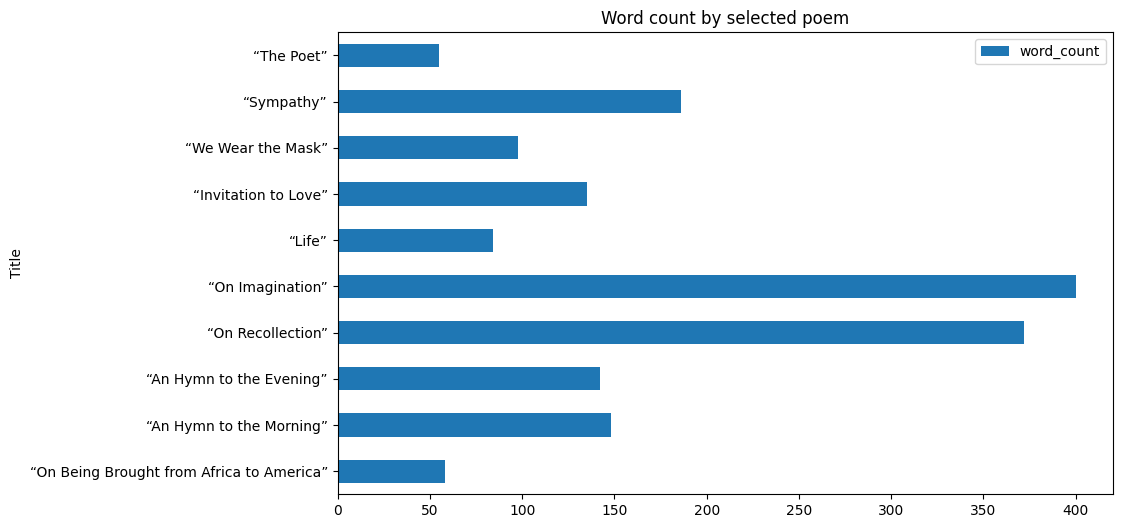

In [31]:
poems.plot.barh(
    x="Title", y="word_count",
    figsize=(10, 6),
    title="Word count by selected poem"
)

Word Cleaning and Frequency


In [15]:
text = poems.loc[0, "Poem_Text"]
words = text.lower().split()
words[:20]

['’twas',
 'mercy',
 'brought',
 'me',
 'from',
 'my',
 'pagan',
 'land,',
 'taught',
 'my',
 'benighted',
 'soul',
 'to',
 'understand',
 'that',
 'there’s',
 'a',
 'god,',
 'that',
 'there’s']

In [16]:
import re

clean_words = re.findall(r"[a-z]+(?:['’][a-z]+)*", text.lower())
clean_words[:20]

['twas',
 'mercy',
 'brought',
 'me',
 'from',
 'my',
 'pagan',
 'land',
 'taught',
 'my',
 'benighted',
 'soul',
 'to',
 'understand',
 'that',
 'there’s',
 'a',
 'god',
 'that',
 'there’s']

In [17]:
from collections import Counter

In [18]:
Counter(clean_words).most_common(10)

[('a', 3),
 ('my', 2),
 ('that', 2),
 ('there’s', 2),
 ('twas', 1),
 ('mercy', 1),
 ('brought', 1),
 ('me', 1),
 ('from', 1),
 ('pagan', 1)]

In [19]:
stopwords = {"a", "the", "and", "to", "of", "in", "that"}

filtered_words = [word for word in clean_words if word not in stopwords]
Counter(filtered_words).most_common(10)

[('my', 2),
 ('there’s', 2),
 ('twas', 1),
 ('mercy', 1),
 ('brought', 1),
 ('me', 1),
 ('from', 1),
 ('pagan', 1),
 ('land', 1),
 ('taught', 1)]

In [20]:
all_text = " ".join(poems["Poem_Text"])
all_words = re.findall(r"[a-z]+(?:['’][a-z]+)*", all_text.lower())
all_filtered = [word for word in all_words if word not in stopwords]

Counter(all_filtered).most_common(15)

[('her', 20),
 ('with', 19),
 ('my', 18),
 ('is', 16),
 ('when', 16),
 ('from', 15),
 ('thy', 15),
 ('come', 14),
 ('but', 13),
 ('i', 12),
 ('his', 12),
 ('we', 12),
 ('he', 12),
 ('our', 10),
 ('all', 10)]

In [21]:
stopwords.update({
    "her", "with", "my", "is", "when", "from", "thy",
    "but", "i", "his", "we", "he", "our", "all",
    "me", "your", "you", "thee", "thou", "she",
    "they", "it", "for", "as", "on", "by", "was",
    "were", "be", "are", "this", "not", "so"
})

In [22]:
all_filtered = [word for word in all_words if word not in stopwords]
Counter(all_filtered).most_common(15)

[('come', 14),
 ('their', 9),
 ('may', 9),
 ('through', 9),
 ('now', 7),
 ('ev’ry', 7),
 ('o', 7),
 ('know', 7),
 ('or', 7),
 ('bird', 7),
 ('th', 6),
 ('bright', 6),
 ('what', 6),
 ('who', 6),
 ('pow’r', 6)]

In [23]:
wheatley_text = " ".join(
    poems.loc[poems["Author"] == "Phillis Wheatley", "Poem_Text"]
)
wheatley_words = re.findall(
    r"[a-z]+(?:['’][a-z]+)*", wheatley_text.lower()
)
wheatley_filtered = [
    word for word in wheatley_words if word not in stopwords
]

Counter(wheatley_filtered).most_common(15)

[('their', 9),
 ('may', 8),
 ('through', 8),
 ('ev’ry', 7),
 ('th', 6),
 ('now', 6),
 ('who', 6),
 ('pow’r', 6),
 ('how', 6),
 ('ye', 5),
 ('song', 5),
 ('skies', 5),
 ('mneme', 5),
 ('bright', 4),
 ('aurora', 4)]

In [25]:
dunbar_text = " ".join(
    poems.loc[poems["Author"] == "Paul Laurence Dunbar", "Poem_Text"]
)
dunbar_words = re.findall(
    r"[a-z]+(?:['’][a-z]+)*", dunbar_text.lower()
)
dunbar_filtered = [
    word for word in dunbar_words if word not in stopwords
]

Counter(dunbar_filtered).most_common(15)

[('come', 14),
 ('bird', 7),
 ('love', 6),
 ('know', 6),
 ('or', 5),
 ('welcome', 5),
 ('why', 5),
 ('caged', 5),
 ('smile', 4),
 ('joy', 3),
 ('life', 3),
 ('bars', 3),
 ('soft', 3),
 ('o', 3),
 ('heart', 3)]

In [26]:
poems["bird_count"] = poems["Poem_Text"].str.lower().str.count(r"\bbird\b")
poems[["Author", "Title", "bird_count"]]

,Author,Title,bird_count
0,Phillis Wheatley,“On Being Brought from Africa to America”,0
1,Phillis Wheatley,“An Hymn to the Morning”,0
2,Phillis Wheatley,“An Hymn to the Evening”,0
3,Phillis Wheatley,“On Recollection”,0
4,Phillis Wheatley,“On Imagination”,0
5,Paul Laurence Dunbar,“Life”,0
6,Paul Laurence Dunbar,“Invitation to Love”,1
7,Paul Laurence Dunbar,“We Wear the Mask”,0
8,Paul Laurence Dunbar,“Sympathy”,6
9,Paul Laurence Dunbar,“The Poet”,0


In [27]:
poems["love_count"] = poems["Poem_Text"].str.lower().str.count(r"\blove\b")
poems[["Author", "Title", "love_count"]]

,Author,Title,love_count
0,Phillis Wheatley,“On Being Brought from Africa to America”,0
1,Phillis Wheatley,“An Hymn to the Morning”,0
2,Phillis Wheatley,“An Hymn to the Evening”,0
3,Phillis Wheatley,“On Recollection”,0
4,Phillis Wheatley,“On Imagination”,0
5,Paul Laurence Dunbar,“Life”,1
6,Paul Laurence Dunbar,“Invitation to Love”,3
7,Paul Laurence Dunbar,“We Wear the Mask”,0
8,Paul Laurence Dunbar,“Sympathy”,0
9,Paul Laurence Dunbar,“The Poet”,2


<Axes: title={'center': 'Bird and love in selected poems'}, ylabel='Title'>

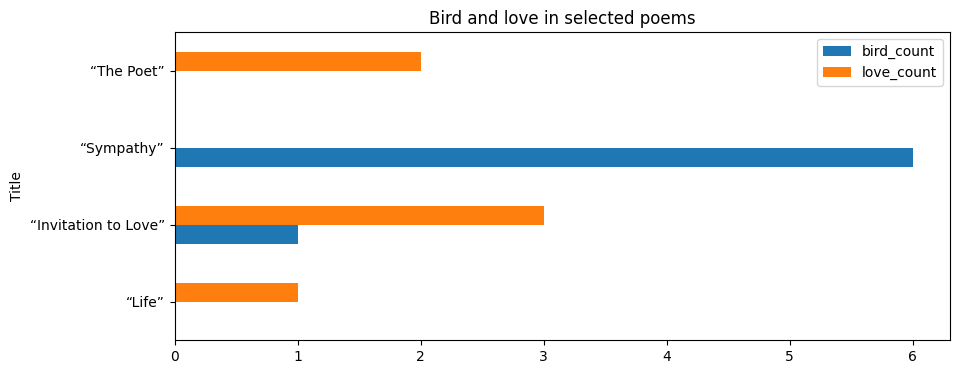

In [32]:
poems.loc[
    (poems["bird_count"] + poems["love_count"]) > 0
].plot.barh(
    x="Title",
    y=["bird_count", "love_count"],
    figsize=(10, 4),
    title="Bird and love in selected poems"
)

In these ten selected poems, “bird” appears seven times across two Dunbar poems, with six uses in “Sympathy.” “Love” appears six times across three Dunbar poems. Neither exact word appears in the five selected Wheatley poems.

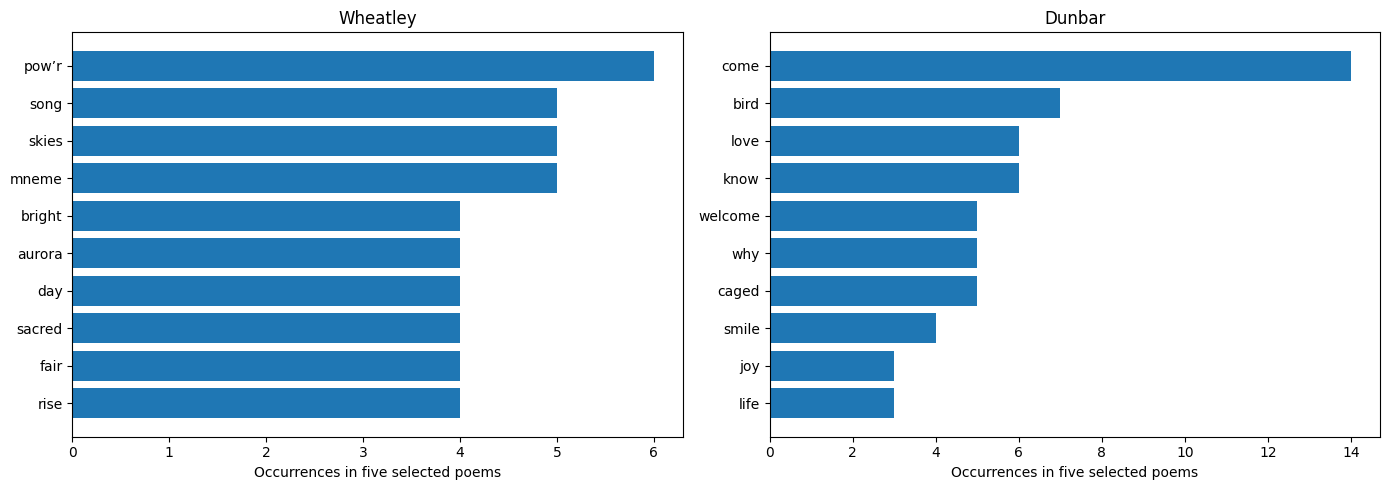

In [30]:
import matplotlib.pyplot as plt

stopwords.update({
    "their", "may", "through", "now", "ev’ry",
    "o", "or", "th", "what", "who", "how", "ye"
})

wheatley_top = Counter(
    word for word in wheatley_words if word not in stopwords
).most_common(10)

dunbar_top = Counter(
    word for word in dunbar_words if word not in stopwords
).most_common(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, author, results in zip(
    axes,
    ["Wheatley", "Dunbar"],
    [wheatley_top, dunbar_top]
):
    words, counts = zip(*results)
    ax.barh(words[::-1], counts[::-1])
    ax.set_title(author)
    ax.set_xlabel("Occurrences in five selected poems")

plt.tight_layout()
plt.show()

the panels have different x-axis scales, and the selected poems contain different total amounts of text. Readers should not compare bar lengths between poets as if they were rates.

Findings and Limitations

In the selected Wheatley poems, “pow’r,” “song,” and “skies” stand out. In the selected Dunbar poems, “come,” “bird,” and “love” stand out.

Looking within poems changed the frequency results: six of the seven uses of bird came from “Sympathy,” while love appeared in three Dunbar poems.

Limit: these are five chosen poems per poet. Their total lengths also differ, so raw word counts alone aren’t a fair measure of which poet uses a word more often overall.